<a href="https://colab.research.google.com/github/Razaurrahmanbennett/CSET_343/blob/main/lab_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#RAZAUR RAHMAN
#e23cseu2442

Dataset loaded successfully!
Shape of dataset: (569, 31)

First 5 rows:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dime

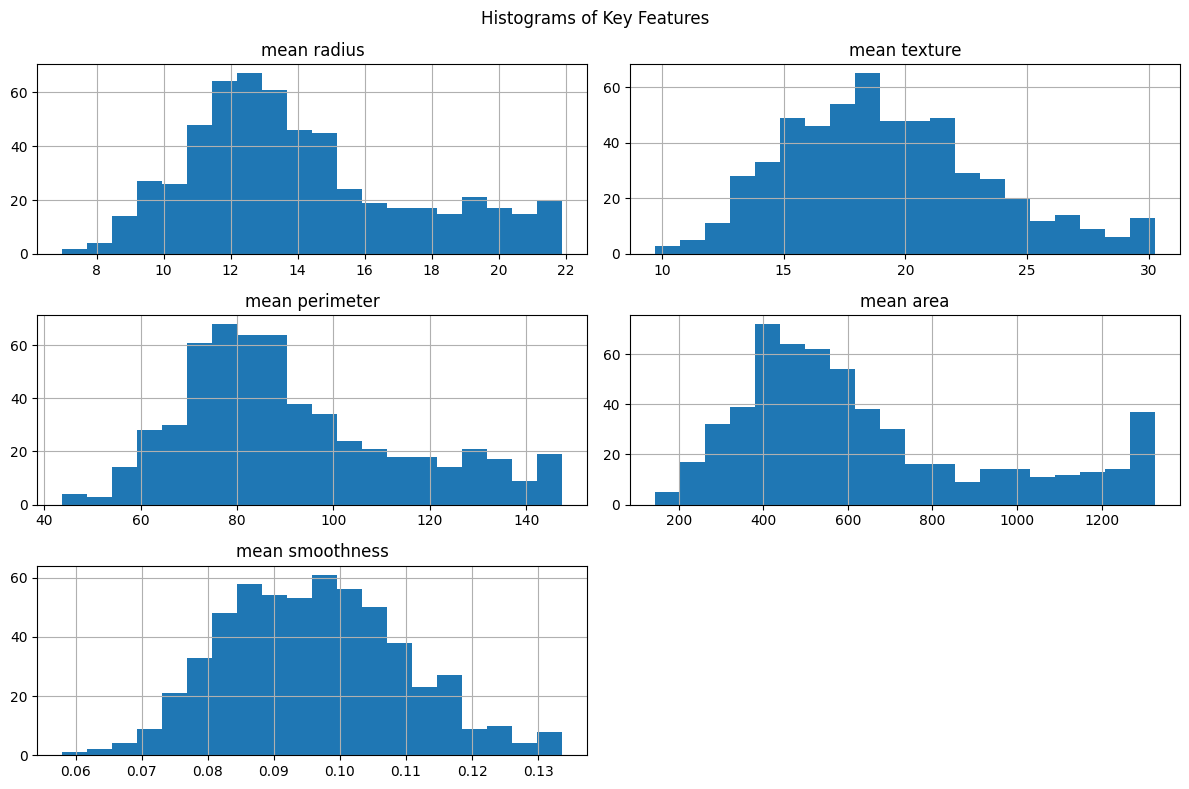

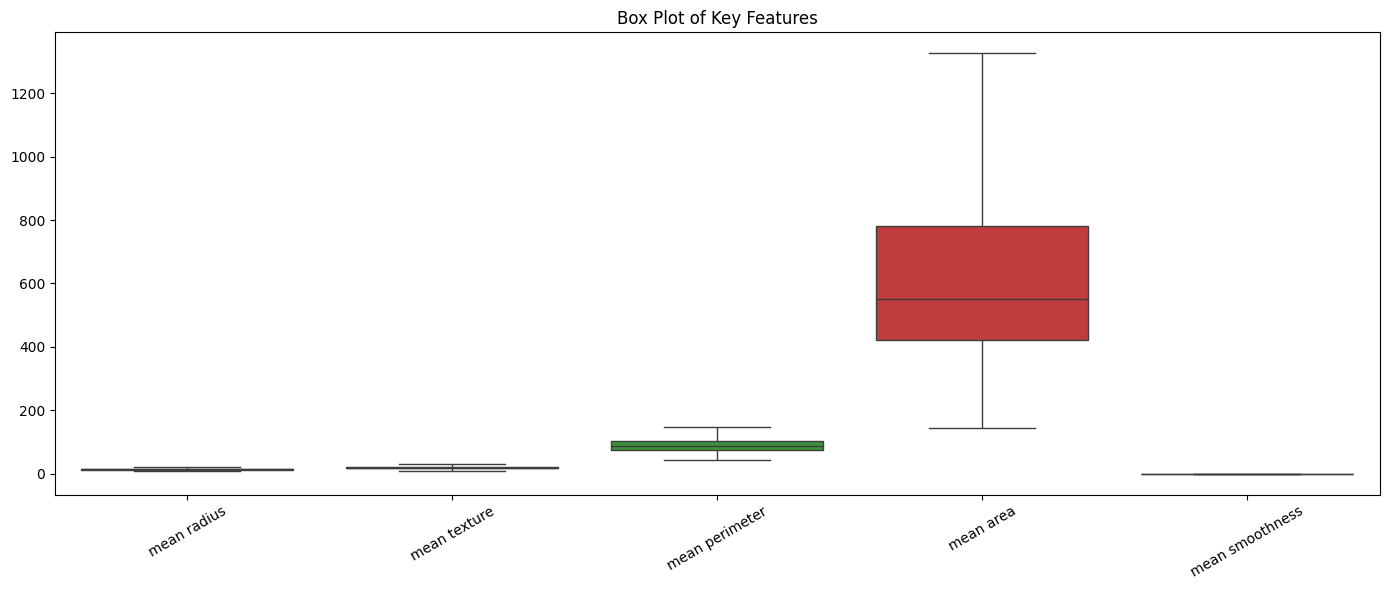

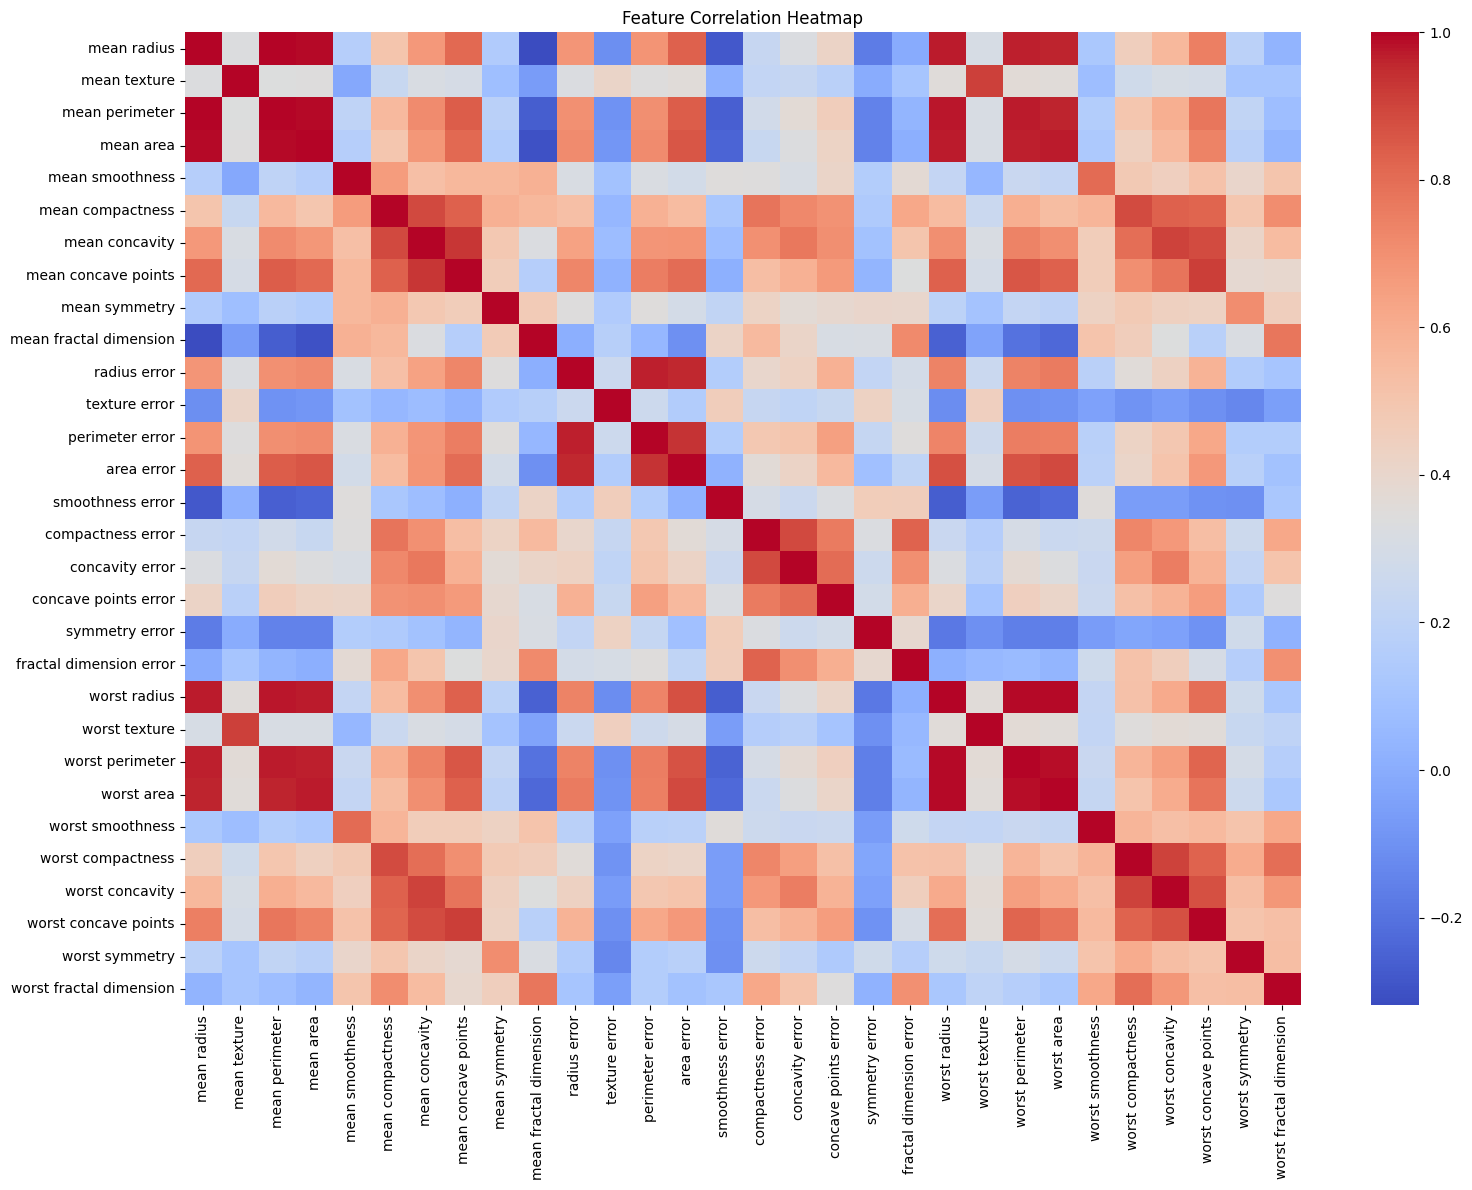


================ CLASS DISTRIBUTION ================

Outcome
1    357
0    212
Name: count, dtype: int64

Class percentages:
Outcome
1    62.741652
0    37.258348
Name: proportion, dtype: float64


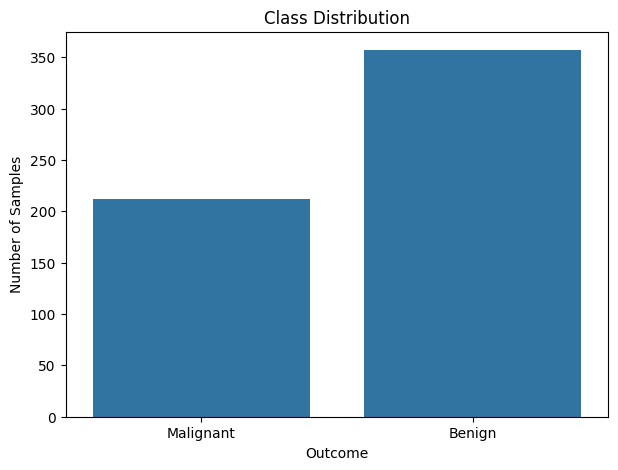


Class 0 - Malignant: 212
Class 1 - Benign: 357

Difference between classes: 145
The dataset shows noticeable class imbalance.

Target encoding:
0 = Malignant
1 = Benign

Feature shape: (569, 30)
Target shape: (569,)

================ DATA SPLIT ================

Training samples: 455
Testing samples: 114

Training class distribution:
Outcome
1    0.626374
0    0.373626
Name: proportion, dtype: float64

Testing class distribution:
Outcome
1    0.631579
0    0.368421
Name: proportion, dtype: float64

Features standardized successfully.

Logistic Regression model trained successfully.

================ ACCURACY ================

Accuracy: 0.9825

================ PRECISION ================

Precision - Malignant: 0.9762
Precision - Benign: 0.9861

================ RECALL ================

Recall - Malignant: 0.9762
Recall - Benign: 0.9861

================ F1 SCORE ================

F1 Score - Malignant: 0.9762
F1 Score - Benign: 0.9861

================ CLASSIFICATION REPORT ===========

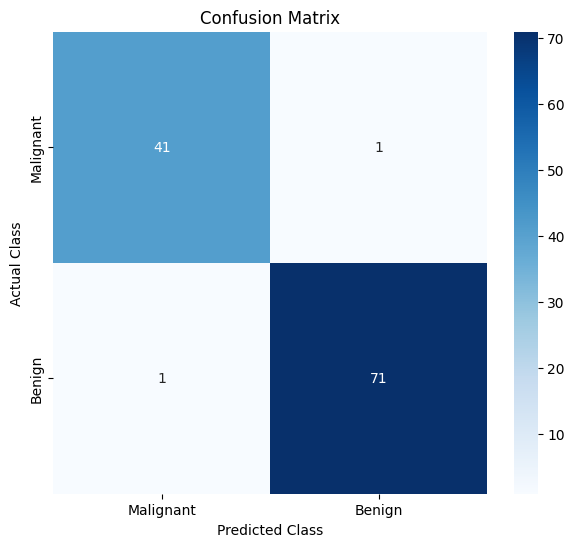


================ ROC-AUC ================

AUC Score: 0.9957


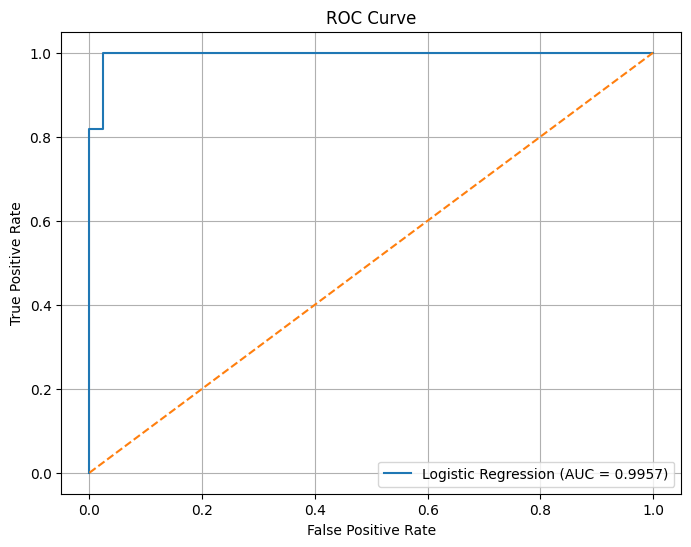


================ FEATURE IMPORTANCE ================

                 Feature  Coefficient
21         worst texture    -1.215472
13            area error    -1.149581
15     compactness error     1.006546
28        worst symmetry    -0.913640
27  worst concave points    -0.897069
23            worst area    -0.869331
24      worst smoothness    -0.804356
20          worst radius    -0.769020
26       worst concavity    -0.751742
10          radius error    -0.751739
1           mean texture    -0.716080
7    mean concave points    -0.693622
6         mean concavity    -0.673383
17  concave points error    -0.668380
22       worst perimeter    -0.636270


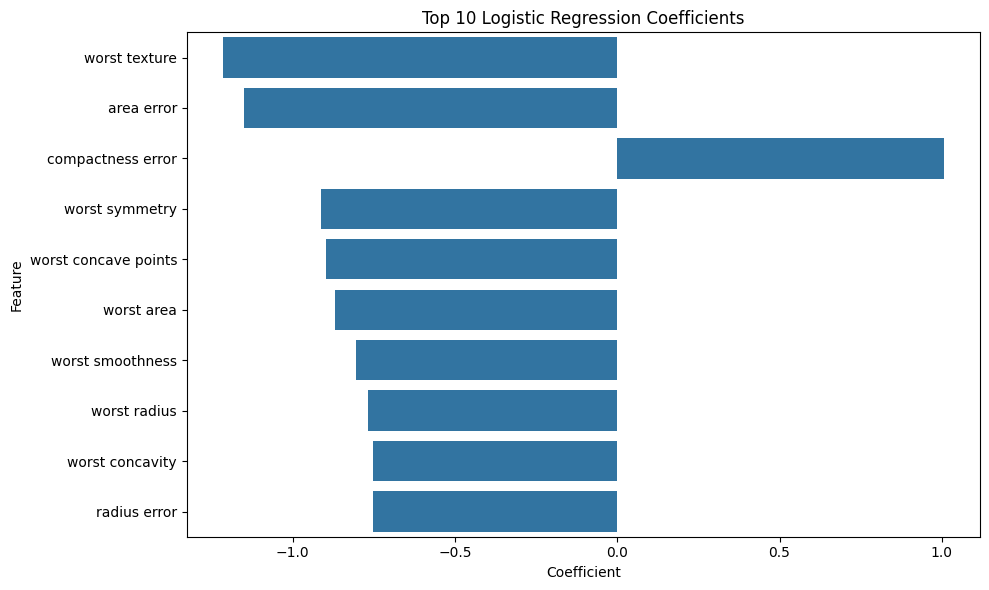


             FINAL MODEL RESULTS
Accuracy  : 0.9825
AUC Score : 0.9957

Malignant Class:
Precision : 0.9762
Recall    : 0.9762
F1 Score  : 0.9762

Benign Class:
Precision : 0.9861
Recall    : 0.9861
F1 Score  : 0.9861


In [1]:
# ============================================================
# LAB ASSIGNMENT - 4
# AI IN HEALTHCARE
# Logistic Regression - Breast Cancer Wisconsin Dataset
# ============================================================

# ------------------------------------------------------------
# 1. IMPORT REQUIRED LIBRARIES
# ------------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

import warnings
warnings.filterwarnings("ignore")


# ------------------------------------------------------------
# 2. DATA ACQUISITION AND LOADING
# ------------------------------------------------------------

# Load Breast Cancer Wisconsin (Diagnostic) dataset
data = load_breast_cancer()

# Create DataFrame
X = pd.DataFrame(data.data, columns=data.feature_names)

# Target variable
y = pd.Series(data.target, name="Outcome")

# Combine features and target
df = pd.concat([X, y], axis=1)

print("Dataset loaded successfully!")
print("Shape of dataset:", df.shape)

print("\nFirst 5 rows:")
print(df.head())


# ------------------------------------------------------------
# 3. BASIC DATA EXPLORATION
# ------------------------------------------------------------

print("\nDataset Information:")
print(df.info())

print("\nDataset Description:")
print(df.describe())


# ------------------------------------------------------------
# 4. SUMMARY STATISTICS
# Mean, Median, Standard Deviation
# ------------------------------------------------------------

print("\n================ SUMMARY STATISTICS ================\n")

summary = pd.DataFrame({
    "Mean": X.mean(),
    "Median": X.median(),
    "Standard Deviation": X.std(),
    "Minimum": X.min(),
    "Maximum": X.max()
})

print(summary)


# ------------------------------------------------------------
# 5. CHECK FOR MISSING VALUES
# ------------------------------------------------------------

print("\n================ MISSING VALUES ================\n")

missing_values = df.isnull().sum()

print(missing_values)

print("\nTotal missing values:", df.isnull().sum().sum())


# ------------------------------------------------------------
# 6. CHECK FOR DUPLICATES
# ------------------------------------------------------------

print("\n================ DUPLICATES ================\n")

duplicates = df.duplicated().sum()

print("Number of duplicate rows:", duplicates)

# Remove duplicates if present
if duplicates > 0:
    df = df.drop_duplicates()
    print("Duplicates removed.")
else:
    print("No duplicate rows found.")


# ------------------------------------------------------------
# 7. CHECK FOR OUTLIERS USING IQR
# ------------------------------------------------------------

print("\n================ OUTLIER DETECTION ================\n")

def detect_outliers_iqr(dataframe):
    outlier_counts = {}

    for column in dataframe.columns:
        Q1 = dataframe[column].quantile(0.25)
        Q3 = dataframe[column].quantile(0.75)

        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        count = ((dataframe[column] < lower_bound) |
                 (dataframe[column] > upper_bound)).sum()

        outlier_counts[column] = count

    return pd.Series(outlier_counts)


outliers = detect_outliers_iqr(X)

print(outliers.sort_values(ascending=False))


# ------------------------------------------------------------
# 8. HANDLE OUTLIERS
# Using IQR Capping
# ------------------------------------------------------------

X_clean = X.copy()

for column in X_clean.columns:

    Q1 = X_clean[column].quantile(0.25)
    Q3 = X_clean[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Cap outliers instead of deleting medical observations
    X_clean[column] = X_clean[column].clip(
        lower=lower_bound,
        upper=upper_bound
    )

print("\nOutliers handled using IQR capping.")


# ------------------------------------------------------------
# 9. HISTOGRAMS OF KEY FEATURES
# ------------------------------------------------------------

key_features = [
    "mean radius",
    "mean texture",
    "mean perimeter",
    "mean area",
    "mean smoothness"
]

X_clean[key_features].hist(
    figsize=(12, 8),
    bins=20
)

plt.suptitle("Histograms of Key Features")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 10. BOXPLOTS
# ------------------------------------------------------------

plt.figure(figsize=(14, 6))

sns.boxplot(
    data=X_clean[key_features]
)

plt.title("Box Plot of Key Features")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 11. CORRELATION HEATMAP
# ------------------------------------------------------------

plt.figure(figsize=(16, 12))

correlation_matrix = X_clean.corr()

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    annot=False
)

plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 12. CLASS DISTRIBUTION
# ------------------------------------------------------------

print("\n================ CLASS DISTRIBUTION ================\n")

print(df["Outcome"].value_counts())

print("\nClass percentages:")
print(df["Outcome"].value_counts(normalize=True) * 100)


plt.figure(figsize=(7, 5))

sns.countplot(
    x=df["Outcome"]
)

plt.title("Class Distribution")
plt.xlabel("Outcome")
plt.ylabel("Number of Samples")

plt.xticks(
    [0, 1],
    ["Malignant", "Benign"]
)

plt.show()


# ------------------------------------------------------------
# 13. EXAMINE CLASS IMBALANCE
# ------------------------------------------------------------

class_counts = df["Outcome"].value_counts()

print("\nClass 0 - Malignant:", class_counts[0])
print("Class 1 - Benign:", class_counts[1])

difference = abs(class_counts[0] - class_counts[1])

print("\nDifference between classes:", difference)

if difference > 0.2 * len(df):
    print("The dataset shows noticeable class imbalance.")
else:
    print("The dataset is reasonably balanced, although the classes are not exactly equal.")


# ------------------------------------------------------------
# 14. ENCODE TARGET VARIABLE AS BINARY
# ------------------------------------------------------------

# In this dataset:
# 0 = Malignant
# 1 = Benign

y = df["Outcome"]

print("\nTarget encoding:")
print("0 = Malignant")
print("1 = Benign")


# ------------------------------------------------------------
# 15. DEFINE FEATURES AND TARGET
# ------------------------------------------------------------

X = X_clean

y = df["Outcome"]

print("\nFeature shape:", X.shape)
print("Target shape:", y.shape)


# ------------------------------------------------------------
# 16. TRAIN-TEST SPLIT
# Stratified sampling maintains class distribution
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\n================ DATA SPLIT ================\n")

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

print("\nTraining class distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting class distribution:")
print(y_test.value_counts(normalize=True))


# ------------------------------------------------------------
# 17. FEATURE STANDARDIZATION
# ------------------------------------------------------------

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("\nFeatures standardized successfully.")


# ------------------------------------------------------------
# 18. TRAIN LOGISTIC REGRESSION MODEL
# ------------------------------------------------------------

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(
    X_train_scaled,
    y_train
)

print("\nLogistic Regression model trained successfully.")


# ------------------------------------------------------------
# 19. MAKE PREDICTIONS
# ------------------------------------------------------------

y_pred = model.predict(X_test_scaled)

# Probability of class 1 (Benign)
y_probability = model.predict_proba(X_test_scaled)[:, 1]


# ------------------------------------------------------------
# 20. ACCURACY
# ------------------------------------------------------------

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("\n================ ACCURACY ================\n")

print("Accuracy:", round(accuracy, 4))


# ------------------------------------------------------------
# 21. PRECISION
# ------------------------------------------------------------

precision = precision_score(
    y_test,
    y_pred,
    average=None
)

print("\n================ PRECISION ================\n")

print("Precision - Malignant:", round(precision[0], 4))
print("Precision - Benign:", round(precision[1], 4))


# ------------------------------------------------------------
# 22. RECALL
# ------------------------------------------------------------

recall = recall_score(
    y_test,
    y_pred,
    average=None
)

print("\n================ RECALL ================\n")

print("Recall - Malignant:", round(recall[0], 4))
print("Recall - Benign:", round(recall[1], 4))


# ------------------------------------------------------------
# 23. F1 SCORE
# ------------------------------------------------------------

f1 = f1_score(
    y_test,
    y_pred,
    average=None
)

print("\n================ F1 SCORE ================\n")

print("F1 Score - Malignant:", round(f1[0], 4))
print("F1 Score - Benign:", round(f1[1], 4))


# ------------------------------------------------------------
# 24. COMPLETE CLASSIFICATION REPORT
# ------------------------------------------------------------

print("\n================ CLASSIFICATION REPORT ================\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Malignant", "Benign"]
    )
)


# ------------------------------------------------------------
# 25. CONFUSION MATRIX
# ------------------------------------------------------------

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\n================ CONFUSION MATRIX ================\n")

print(cm)


# Visualize confusion matrix
plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Malignant", "Benign"],
    yticklabels=["Malignant", "Benign"]
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix")

plt.show()


# ------------------------------------------------------------
# 26. ROC CURVE
# ------------------------------------------------------------

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_probability
)

# Calculate AUC
auc_score = roc_auc_score(
    y_test,
    y_probability
)

print("\n================ ROC-AUC ================\n")

print("AUC Score:", round(auc_score, 4))


# Plot ROC curve
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {auc_score:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.grid()

plt.show()


# ------------------------------------------------------------
# 27. MODEL COEFFICIENTS
# For Model Interpretation
# ------------------------------------------------------------

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coefficients["Absolute_Coefficient"] = (
    coefficients["Coefficient"].abs()
)

coefficients = coefficients.sort_values(
    by="Absolute_Coefficient",
    ascending=False
)

print("\n================ FEATURE IMPORTANCE ================\n")

print(
    coefficients[
        ["Feature", "Coefficient"]
    ].head(15)
)


# ------------------------------------------------------------
# 28. VISUALIZE TOP MODEL FEATURES
# ------------------------------------------------------------

top_features = coefficients.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_features,
    x="Coefficient",
    y="Feature"
)

plt.title("Top 10 Logistic Regression Coefficients")

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# 29. FINAL RESULTS SUMMARY
# ------------------------------------------------------------

print("\n====================================================")
print("             FINAL MODEL RESULTS")
print("====================================================")

print(f"Accuracy  : {accuracy:.4f}")
print(f"AUC Score : {auc_score:.4f}")

print("\nMalignant Class:")
print(f"Precision : {precision[0]:.4f}")
print(f"Recall    : {recall[0]:.4f}")
print(f"F1 Score  : {f1[0]:.4f}")

print("\nBenign Class:")
print(f"Precision : {precision[1]:.4f}")
print(f"Recall    : {recall[1]:.4f}")
print(f"F1 Score  : {f1[1]:.4f}")

print("====================================================")